In [47]:
import xenomorph.geometry as gm
import xenomorph.systems as wrb

In [48]:
velocity_structure, particles = gm.radial_velocity_points(wrb.WR140, shells=10, bins=10, n_t=1000, n_points=400)

In [49]:
velocity_cube, xedges, yedges = gm.radial_velocity_cube(wrb.WR140, velocity_structure, particles, resolution=600)

In [50]:
import matplotlib.pyplot as plt
import numpy as np
bins = 10

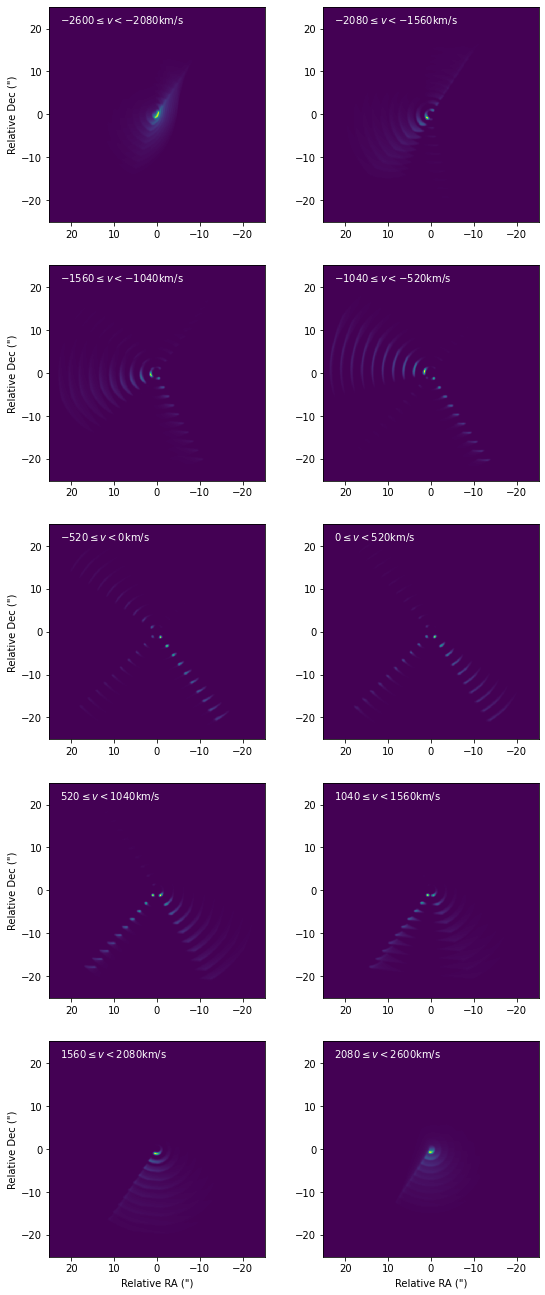

In [51]:
fig, axes = plt.subplots(ncols=2, nrows=5, figsize=(9, 23))

for i in range(5):
    for j in range(2):
        bin_no = 2*i+j
        axes[i, j].pcolormesh(-xedges, yedges, velocity_cube[:, :, bin_no] / np.max(velocity_cube))
        lower, upper = velocity_structure['bin_centres'][bin_no] - velocity_structure['bin_width'] / 2, velocity_structure['bin_centres'][bin_no] + velocity_structure['bin_width'] / 2
        text = fr"${lower:.0f}\leq v < {upper:.0f}$km/s"
        axes[i, j].text(-0.9 * np.min(xedges), 0.85 * np.max(yedges), text, c='w')
        axes[i, j].set(aspect='equal')
        axes[i, j].xaxis.set_inverted(True)
        if i == 4:
            axes[i, j].set_xlabel('Relative RA (")')
        if j == 0:
            axes[i, j].set_ylabel('Relative Dec (")')